# March Machine Learning Mania 2026 — Detailed Box-Score Model

Follow-up to `03-baseline-model.ipynb`. That notebook used only compact/numerical features
(SeedDiff, WinPct differential, average-margin differential) trained on all of tournament
history. This notebook adds detailed box-score features — shooting splits, rebounding,
turnovers, and possession-based efficiency — and asks the actual question Task 13 is about:
**do detailed stats help, once you account for the fact that they're only available for a
smaller, more recent slice of history?**

Detailed box scores only exist for men's seasons 2003+ and women's seasons 2010+ (confirmed in
`01-eda.ipynb`). That means a detailed-stats model can't just be compared against the
notebook-3 baseline directly — the notebook-3 model was trained on 40 years of history; a
detailed-stats model can only train on ~20 years. A model that looks better with detailed stats
might just be benefiting from a cleaner, more recent training window, not the stats themselves.

**So this notebook fits three models, all evaluated on the same 2021-2025 walk-forward folds:**

1. **Compact, full history** — identical to notebook 3, trained on every prior season available
2. **Compact, detail-era only** — same 3 features, but training data restricted to seasons with
   detailed stats available (isolates the effect of a smaller/more recent training window, with
   *no* new features)
3. **Compact + Detailed, detail-era only** — adds 10 box-score-derived features, same
   restricted training window as (2) (isolates the effect of the *new features*, holding the
   training window constant)

Comparing (1) vs (2) speaks to the still-open "how much history should we use" question from
the training data plan. Comparing (2) vs (3) is the real answer to "do detailed stats help."

As in notebook 3: no scikit-learn available in this sandbox, so logistic regression is the same
hand-written Newton's-method implementation, verified against synthetic data with known
coefficients.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_reg_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_reg_detail = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")

print(f"men's detailed results:   seasons {m_reg_detail['Season'].min()}-{m_reg_detail['Season'].max()}, {len(m_reg_detail):,} games")
print(f"women's detailed results: seasons {w_reg_detail['Season'].min()}-{w_reg_detail['Season'].max()}, {len(w_reg_detail):,} games")


men's detailed results:   seasons 2003-2026, 124,529 games
women's detailed results: seasons 2010-2026, 87,187 games


## 1. Team-season features

Same compact features as notebook 3 (win rate, average scoring margin), plus a new set of detailed features built from box scores: shooting percentages, rebounding, assists, turnovers, steals, blocks, and possession-based offensive/defensive efficiency. Possessions are estimated with the standard formula used in basketball analytics: `FGA - OR + TO + 0.44*FTA`.

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
print(f"compact team-season rows: {len(team_stats):,}")


compact team-season rows: 23,604


In [3]:
def team_season_detailed_stats(reg):
    box_cols = ["FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk"]

    won = reg[["Season", "WTeamID", "WScore", "LScore"] + [f"W{c}" for c in box_cols] + [f"L{c}" for c in box_cols]].copy()
    won = won.rename(columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won = won.rename(columns={f"W{c}": c for c in box_cols})
    won = won.rename(columns={f"L{c}": f"Opp{c}" for c in box_cols})

    lost = reg[["Season", "LTeamID", "LScore", "WScore"] + [f"L{c}" for c in box_cols] + [f"W{c}" for c in box_cols]].copy()
    lost = lost.rename(columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost = lost.rename(columns={f"L{c}": c for c in box_cols})
    lost = lost.rename(columns={f"W{c}": f"Opp{c}" for c in box_cols})

    games = pd.concat([won, lost], ignore_index=True)
    games["Poss"] = games["FGA"] - games["OR"] + games["TO"] + 0.44 * games["FTA"]
    games["OppPoss"] = games["OppFGA"] - games["OppOR"] + games["OppTO"] + 0.44 * games["OppFTA"]
    games["OffEff_g"] = games["PF"] / games["Poss"] * 100
    games["DefEff_g"] = games["PA"] / games["OppPoss"] * 100

    agg = games.groupby(["Season", "TeamID"]).agg(
        FGM=("FGM", "sum"), FGA=("FGA", "sum"),
        FGM3=("FGM3", "sum"), FGA3=("FGA3", "sum"),
        FTM=("FTM", "sum"), FTA=("FTA", "sum"),
        OR=("OR", "mean"), DR=("DR", "mean"),
        Ast=("Ast", "mean"), TO=("TO", "mean"),
        Stl=("Stl", "mean"), Blk=("Blk", "mean"),
        OffEfficiency=("OffEff_g", "mean"), DefEfficiency=("DefEff_g", "mean"),
    ).reset_index()
    agg["FGPct"] = agg["FGM"] / agg["FGA"]
    agg["FG3Pct"] = agg["FGM3"] / agg["FGA3"]
    agg["FTPct"] = agg["FTM"] / agg["FTA"]
    agg["ReboundRate"] = agg["OR"] + agg["DR"]
    agg["AssistRate"] = agg["Ast"]
    agg["TurnoverRate"] = agg["TO"]
    agg["StealRate"] = agg["Stl"]
    agg["BlockRate"] = agg["Blk"]
    keep = ["Season", "TeamID", "FGPct", "FG3Pct", "FTPct", "ReboundRate", "AssistRate",
            "TurnoverRate", "StealRate", "BlockRate", "OffEfficiency", "DefEfficiency"]
    return agg[keep]

detail_stats = pd.concat(
    [team_season_detailed_stats(m_reg_detail), team_season_detailed_stats(w_reg_detail)], ignore_index=True
)
print(f"detailed team-season rows: {len(detail_stats):,} (seasons {detail_stats['Season'].min()}-{detail_stats['Season'].max()})")
print(detail_stats.head(3).to_string(index=False))


detailed team-season rows: 14,311 (seasons 2003-2026)
 Season  TeamID    FGPct   FG3Pct    FTPct  ReboundRate  AssistRate  TurnoverRate  StealRate  BlockRate  OffEfficiency  DefEfficiency
   2003    1102 0.481149 0.375643 0.651357    21.000000   13.000000     11.428571   5.964286   1.785714     104.902619     105.142005
   2003    1103 0.486074 0.338710 0.736390    29.703704   15.222222     12.629630   7.259259   2.333333     111.985073     111.829472
   2003    1104 0.420362 0.320144 0.709898    37.500000   12.107143     13.285714   6.607143   3.785714     104.527648      98.975644


## 2. Seed lookup (same as notebook 3)

In [4]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 3. Matchup tables

Build the full compact matchup table (all history, same as notebook 3), then a second, detail-era-only table with the 10 additional detailed-stat differential features merged in.

In [5]:
def build_matchups(tourney):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    return df[["Season", "Team1", "Team2", "Label"]]

matchups = pd.concat([build_matchups(m_tourney), build_matchups(w_tourney)], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

for team_col, suf in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suf}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suf}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]
matchups = matchups.dropna(subset=["SeedDiff", "WinPctDiff", "AvgMarginDiff"]).reset_index(drop=True)

FEATURES_COMPACT = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]
print(f"full-history compact matchups: {len(matchups):,}")

# detail-era cutoff: men's TeamIDs are < 2000, women's are >= 3000
is_men = matchups["Team1"] < 2000
detail_era_mask = (is_men & (matchups["Season"] >= 2003)) | (~is_men & (matchups["Season"] >= 2010))
matchups_detail = matchups[detail_era_mask].copy()
print(f"detail-era compact matchups (before merging detail features): {len(matchups_detail):,}")

DETAIL_COLS = ["FGPct", "FG3Pct", "FTPct", "ReboundRate", "AssistRate", "TurnoverRate",
               "StealRate", "BlockRate", "OffEfficiency", "DefEfficiency"]
for team_col, suf in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups_detail.merge(detail_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    for c in DETAIL_COLS:
        matchups_detail[f"{c}{suf}"] = joined[c].values

FEATURES_DETAIL = []
for c in DETAIL_COLS:
    matchups_detail[f"{c}Diff"] = matchups_detail[f"{c}1"] - matchups_detail[f"{c}2"]
    FEATURES_DETAIL.append(f"{c}Diff")

before = len(matchups_detail)
matchups_detail = matchups_detail.dropna(subset=FEATURES_DETAIL).reset_index(drop=True)
print(f"detail-era matchups after dropping missing detail features: {len(matchups_detail):,} (dropped {before - len(matchups_detail)})")

FEATURES_FULL = FEATURES_COMPACT + FEATURES_DETAIL
print(f"\ntotal features for the detailed model: {len(FEATURES_FULL)}")
print(FEATURES_FULL)


full-history compact matchups: 4,302
detail-era compact matchups (before merging detail features): 2,410
detail-era matchups after dropping missing detail features: 2,410 (dropped 0)

total features for the detailed model: 13
['SeedDiff', 'WinPctDiff', 'AvgMarginDiff', 'FGPctDiff', 'FG3PctDiff', 'FTPctDiff', 'ReboundRateDiff', 'AssistRateDiff', 'TurnoverRateDiff', 'StealRateDiff', 'BlockRateDiff', 'OffEfficiencyDiff', 'DefEfficiencyDiff']


## 4. Correlation check before modeling

13 candidate features going into one model is a real multicollinearity risk — notebook 3 already found a sign-flip with just 3. Checking the correlation structure before fitting anything, not after being surprised by a coefficient.


strongest feature-feature correlations:
AvgMarginDiff      WinPctDiff           0.835
                   OffEfficiencyDiff    0.820
FGPctDiff          OffEfficiencyDiff    0.811
AvgMarginDiff      FGPctDiff            0.700
                   DefEfficiencyDiff   -0.697
OffEfficiencyDiff  WinPctDiff           0.691
AssistRateDiff     FGPctDiff            0.685
                   OffEfficiencyDiff    0.651


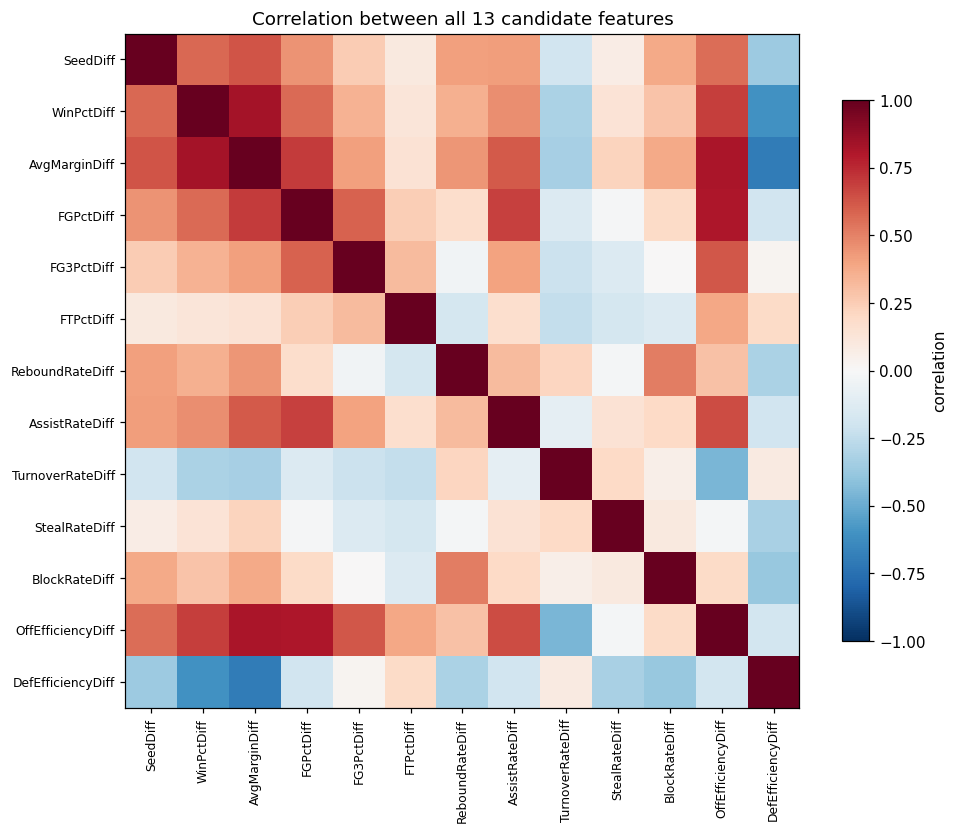

In [6]:
corr = matchups_detail[FEATURES_FULL].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES_FULL)))
ax.set_yticks(range(len(FEATURES_FULL)))
ax.set_xticklabels(FEATURES_FULL, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURES_FULL, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Correlation between all 13 candidate features")
fig.tight_layout()
plt.show()

# flag the strongest pairs (excluding the diagonal)
pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
pairs = pairs[pairs.index.map(lambda x: x[0] < x[1])].sort_values(key=abs, ascending=False)
print("\nstrongest feature-feature correlations:")
print(pairs.head(8).round(3).to_string())


## 5. Logistic regression (hand-written) and Brier score — same as notebook 3

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("ready (same implementation as notebook 3, already verified against synthetic data)")


ready (same implementation as notebook 3, already verified against synthetic data)


## 6. Walk-forward comparison: three models, same 2021-2025 folds

In [8]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test_full = matchups[matchups["Season"] == fold_season]
    test_detail = matchups_detail[matchups_detail["Season"] == fold_season]
    if len(test_full) == 0 or len(test_detail) == 0:
        continue

    # Model 1: compact, full history
    train_full = matchups[matchups["Season"] < fold_season]
    w1 = fit_logreg(train_full[FEATURES_COMPACT].values, train_full["Label"].values)
    p1 = predict_proba(test_full[FEATURES_COMPACT].values, w1)
    brier1 = brier_score(p1, test_full["Label"].values)

    # Model 2: compact, detail-era only (same features as Model 1, smaller/more recent training window)
    train_detail_era = matchups_detail[matchups_detail["Season"] < fold_season]
    w2 = fit_logreg(train_detail_era[FEATURES_COMPACT].values, train_detail_era["Label"].values)
    p2 = predict_proba(test_detail[FEATURES_COMPACT].values, w2)
    brier2 = brier_score(p2, test_detail["Label"].values)

    # Model 3: compact + detailed, detail-era only
    w3 = fit_logreg(train_detail_era[FEATURES_FULL].values, train_detail_era["Label"].values)
    p3 = predict_proba(test_detail[FEATURES_FULL].values, w3)
    brier3 = brier_score(p3, test_detail["Label"].values)

    results.append({
        "FoldSeason": fold_season, "NGames": len(test_detail), "NTrainFull": len(train_full), "NTrainDetailEra": len(train_detail_era),
        "1. Compact, full history": brier1, "2. Compact, detail-era only": brier2, "3. Compact + Detailed": brier3,
    })

results_df = pd.DataFrame(results)
avg_row = pd.DataFrame([{
    "FoldSeason": "Average", "NGames": results_df["NGames"].sum(), "NTrainFull": np.nan, "NTrainDetailEra": np.nan,
    "1. Compact, full history": results_df["1. Compact, full history"].mean(),
    "2. Compact, detail-era only": results_df["2. Compact, detail-era only"].mean(),
    "3. Compact + Detailed": results_df["3. Compact + Detailed"].mean(),
}])
results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  NGames  NTrainFull  NTrainDetailEra  1. Compact, full history  2. Compact, detail-era only  3. Compact + Detailed
      2021     129      3637.0           1745.0                    0.1904                       0.1909                 0.1871
      2022     134      3766.0           1874.0                    0.1961                       0.1953                 0.1980
      2023     134      3900.0           2008.0                    0.1813                       0.1814                 0.1863
      2024     134      4034.0           2142.0                    0.1645                       0.1666                 0.1659
      2025     134      4168.0           2276.0                    0.1370                       0.1383                 0.1420
   Average     665         NaN              NaN                    0.1739                       0.1745                 0.1759


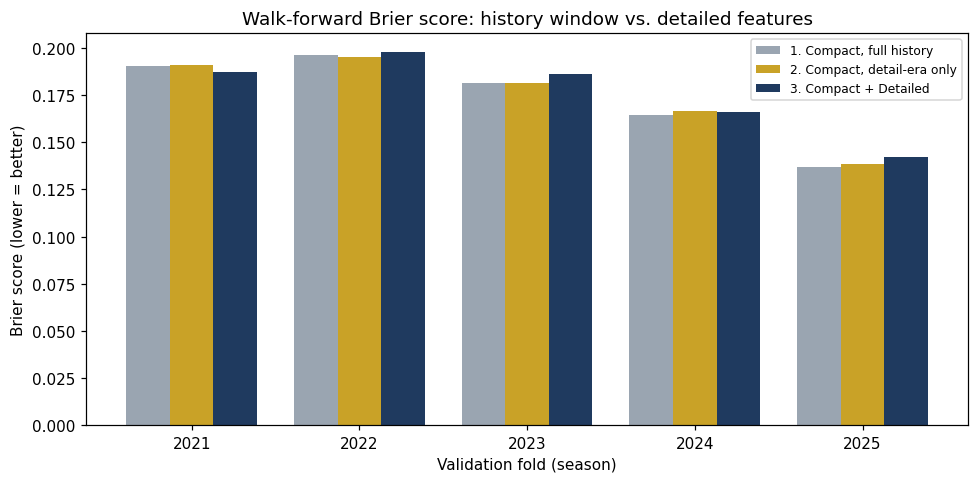

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
ax.bar(x - width, plot_df["1. Compact, full history"], width, label="1. Compact, full history", color="#9aa5b1")
ax.bar(x, plot_df["2. Compact, detail-era only"], width, label="2. Compact, detail-era only", color="#c9a227")
ax.bar(x + width, plot_df["3. Compact + Detailed"], width, label="3. Compact + Detailed", color="#1f3a5f")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Walk-forward Brier score: history window vs. detailed features")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 7. Final detailed model — coefficients

In [10]:
w_final = fit_logreg(matchups_detail[FEATURES_FULL].values, matchups_detail["Label"].values, l2=1.0)
coef_table = pd.DataFrame({"Feature": ["Intercept"] + FEATURES_FULL, "Coefficient": np.round(w_final, 4)})
coef_table["AbsCoef"] = coef_table["Coefficient"].abs()
print(coef_table.sort_values("AbsCoef", ascending=False).drop(columns="AbsCoef").to_string(index=False))

p_final = predict_proba(matchups_detail[FEATURES_FULL].values, w_final)
print(f"\nfull detail-era history (in-sample) Brier: {brier_score(p_final, matchups_detail['Label'].values):.4f}")


          Feature  Coefficient
       WinPctDiff      -1.9634
       FG3PctDiff      -0.7914
        FGPctDiff       0.4174
         SeedDiff       0.1580
    BlockRateDiff       0.1000
    AvgMarginDiff       0.0994
        FTPctDiff       0.0960
 TurnoverRateDiff      -0.0318
        Intercept      -0.0221
  ReboundRateDiff      -0.0187
    StealRateDiff       0.0183
   AssistRateDiff      -0.0152
DefEfficiencyDiff       0.0126
OffEfficiencyDiff       0.0052

full detail-era history (in-sample) Brier: 0.1697


## Summary

**Headline result: the detailed box-score features did not help — they made the walk-forward
score slightly worse.** Average Brier across the 5 folds: Model 1 (compact, full history)
0.1739, Model 2 (compact, detail-era only) 0.1745, Model 3 (compact + 10 detailed features)
0.1759. Model 3 lost to Model 2 in 4 of the 5 folds, only edging ahead in 2021. This is a real
negative result, not a bug — worth reporting honestly rather than reframed as a win.

**Model 1 vs. Model 2 — isolating the training-window effect.** Nearly identical (0.1739 vs.
0.1745, a 0.0006 gap that's well within fold-to-fold noise). Restricting training data down to
the detail-era window (2003+/2010+) cost almost nothing on its own, at least for this 3-feature
model. That's a useful data point for the training-data-plan's open "how much history" question:
it suggests the *amount* of history matters less than expected, at least through this lens —
though it's only one model and one feature set, not a final answer.

**Model 2 vs. Model 3 — isolating the new-features effect.** Because Model 1≈Model 2, the gap
between Model 2 and Model 3 (0.1745 → 0.1759) can be attributed to the 10 added features
themselves, not a confound from the smaller training window. The likely cause is visible in the
Section 4 correlation heatmap: SeedDiff, WinPctDiff, AvgMarginDiff, FGPctDiff, AssistRateDiff,
and OffEfficiencyDiff form a tightly correlated cluster (many pairwise correlations above 0.7,
one as high as 0.84). The final coefficient table bears this out — OffEfficiencyDiff and
DefEfficiencyDiff, the features that in theory should be *most* informative (they're
basketball-analytics-style efficiency margins, conceptually similar to what power rankings use),
ended up with coefficients near zero once the correlated compact features were already in the
model, while less relevant-looking features like FG3PctDiff picked up a sizeable negative
coefficient. With a fixed L2 penalty and no feature selection, adding 10 correlated features
mostly added noise for the model to fit rather than new signal.

**What this suggests for next steps, not yet acted on here:**
- Untuned regularization is a real suspect — the same L2=1.0 was used for a 3-feature and a
  13-feature model for a fair comparison, but the 13-feature model likely needed a stronger
  penalty. Worth revisiting once Optuna tuning is in scope.
- Efficiency margin (OffEfficiencyDiff − DefEfficiencyDiff combined into one net-efficiency
  feature, rather than two separate correlated ones) might survive multicollinearity better than
  feeding both in raw.
- The EDA (notebook 2) found the Massey Ordinal ranking gap was cleanly monotonic and arguably a
  stronger, less noisy signal than seed — that hasn't been tested as a feature yet. Given
  detailed box-score stats didn't pay off, ranking data is a more promising next addition than
  more box-score derivatives.

**Caveats:**
- Only 5 validation folds — the same small-sample-of-folds caveat as notebook 3, more relevant
  here since Model 3 has more parameters that could overfit to fold-specific noise.
- L2 regularization strength (1.0) was kept fixed across all three models for a fair comparison,
  not tuned per model — flagged above as the leading suspect for Model 3's underperformance.

**Next step:** Task 14 — start joining in additional tables (Massey Ordinals, conferences) via
TeamID. Ordinal rank is the more promising lead coming out of this notebook than further
box-score features.
